In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [153]:
df=pd.read_csv(r"D:\Car\Customer_Segmentation\Course_ML_Project\ai_adoption_fortune500_synthetic_dataset_2020_2025.csv")

In [154]:
df.head()

,Year,Company,Industry,Country,Company_Type,Employee_Size,Revenue_USD,Uses_AI,Use_Case,AI_ROI_Percent,AI_Maturity_Score
0,2020,Amazon,E-commerce,USA,Real,Enterprise,4.535464e+11,Yes,Autonomous Driving,30.33,77
1,2021,Amazon,E-commerce,USA,Real,Enterprise,4.878035e+11,Yes,Generative AI,19.09,81
2,2022,Amazon,E-commerce,USA,Real,Enterprise,2.182500e+11,Yes,Supply Chain Optimization,34.99,79
3,2023,Amazon,E-commerce,USA,Real,Enterprise,4.114132e+11,Yes,Chatbots,23.96,72
4,2024,Amazon,E-commerce,USA,Real,Enterprise,3.191970e+11,No,NaN,0.00,27


In [ ]:
print(df.info())
print(df.isnull().sum())

df = df.drop("Company", axis=1)


df["Use_Case"] = df["Use_Case"].fillna("No AI Use Case")


df = df.drop_duplicates()


print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               6000 non-null   int64  
 1   Company            6000 non-null   str    
 2   Industry           6000 non-null   str    
 3   Country            6000 non-null   str    
 4   Company_Type       6000 non-null   str    
 5   Employee_Size      6000 non-null   str    
 6   Revenue_USD        6000 non-null   float64
 7   Uses_AI            6000 non-null   str    
 8   Use_Case           4848 non-null   str    
 9   AI_ROI_Percent     6000 non-null   float64
 10  AI_Maturity_Score  6000 non-null   int64  
dtypes: float64(2), int64(2), str(7)
memory usage: 515.8 KB
None
Year                    0
Company                 0
Industry                0
Country                 0
Company_Type            0
Employee_Size           0
Revenue_USD             0
Uses_AI                 0
Use_Cas

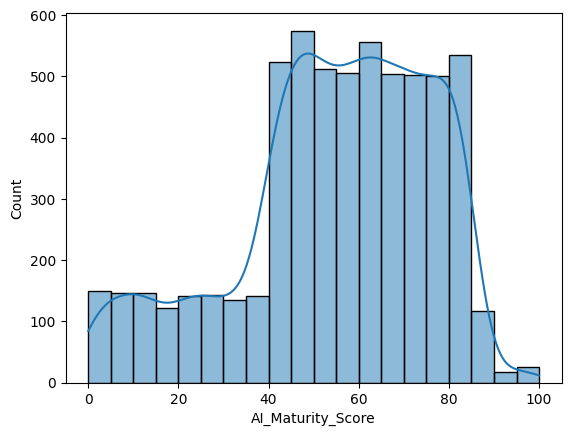

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["AI_Maturity_Score"], bins=20, kde=True)
plt.show()

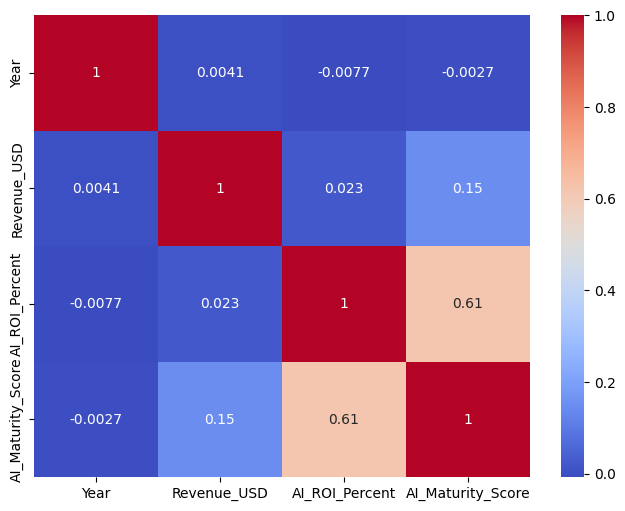

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm")
plt.show()

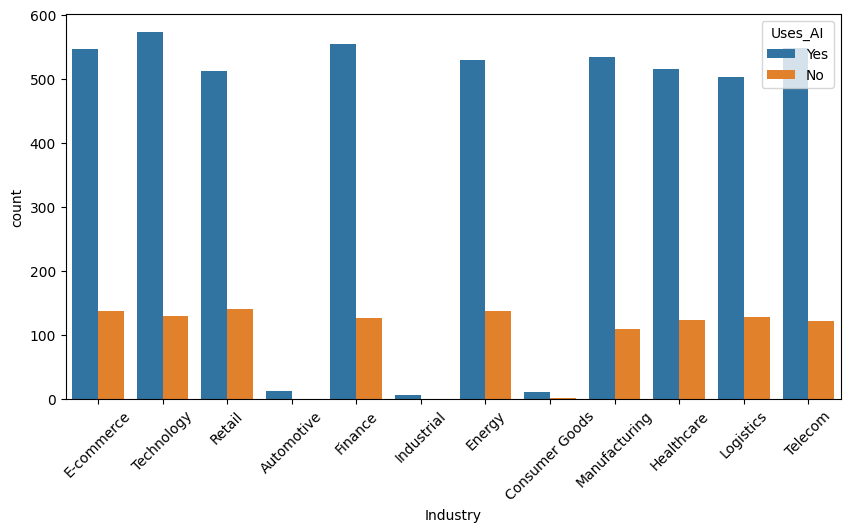

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="Industry",hue="Uses_AI")

plt.xticks(rotation=45)
plt.show()

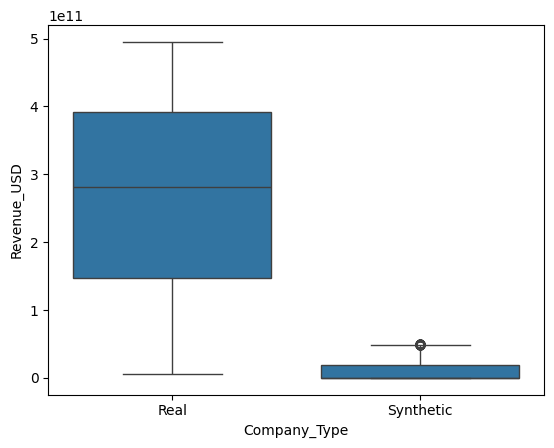

In [ ]:
sns.boxplot(data=df, x="Company_Type",y="Revenue_USD")
plt.show()

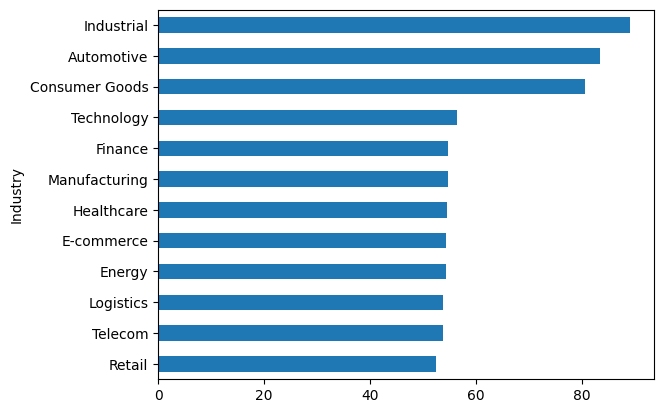

In [ ]:
industry_score = (df.groupby("Industry")["AI_Maturity_Score"].mean().sort_values())

industry_score.plot(kind="barh")
plt.show()

In [ ]:
df["Uses_AI"] = df["Uses_AI"].map({"No":0,"Yes":1})

In [163]:
df["Log_Revenue"] = np.log1p(df["Revenue_USD"])

In [ ]:
df["Employee_Size"] = df["Employee_Size"].map({"Small":0,"Large":1})

In [ ]:
df.drop("Revenue_USD",axis=1,inplace=True)

In [ ]:
X = df.drop("AI_Maturity_Score",axis=1)

y = df["AI_Maturity_Score"]

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(exclude='object').columns

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])

categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_cols),('cat', categorical_transformer, categorical_cols)])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

rf_model = Pipeline([("prep", preprocessor),("model", RandomForestRegressor(n_estimators=300,random_state=42))])

gb_model = Pipeline([("prep", preprocessor),("model", GradientBoostingRegressor(random_state=42))])

In [174]:
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [ ]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

models = {"Random Forest": rf_model,"Gradient Boosting": gb_model}

for name, model in models.items():
    pred = model.predict(X_test)
    print("\n", name)
    print("MAE:",mean_absolute_error(y_test, pred))
    print("RMSE:",np.sqrt(mean_squared_error(y_test, pred)))
    print("R2:",r2_score(y_test, pred))


 Random Forest
MAE: 11.404130555555556
RMSE: 13.344393780202648
R2: 0.6154379368508873

 Gradient Boosting
MAE: 11.29698537566511
RMSE: 13.089972490985934
R2: 0.6299620991446662
